In [2]:
#imports
import pandas as pd
import numpy as np
import seaborn as sns
from sqlalchemy import create_engine
import psycopg2
import subprocess, textwrap
import sys
import os
import matplotlib.pyplot as plt
import proc

In [3]:
# DB config

from dotenv import load_dotenv
load_dotenv()


DB_CONFIG = {
        'dbname': os.getenv('DB_NAME'),
        'user': os.getenv('DB_USER'),
        'password': os.getenv('DB_PASSWORD'),
        'host': os.getenv('DB_HOST'),
        'port': os.getenv('DB_PORT')
    }

db_url = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"

In [4]:
# Run the quick_validation_client.py script and capture its output
result = subprocess.run(
	[sys.executable, "scripts/utils/quick_validation_client.py"],
	cwd=os.path.abspath("."),  # ensure repo root
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
print(result.stdout)
if result.returncode != 0:
	print(result.stderr)
else:
	print("alignment_validation completed successfully.")


STOCK EVENT DATA QUALITY CHECK - 2026-01-04 16:15:05

RECORD COUNTS
d:\Python Projects\stock-event-analysis\scripts\utils\quick_validation_client.py:209: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)

+------------------------+-----------+
| Table                  | Records   |
+========================+===========+
| tickers                | 12        |
+------------------------+-----------+
| stock_prices           | 8,532     |
+------------------------+-----------+
| reddit_posts           | 15,202    |
+------------------------+-----------+
| reddit_post_tickers    | 19,274    |
+------------------------+-----------+
| reddit_post_sentiment  | 19,274    |
+------------------------+-----------+
| news_articles          | 32,849    |
+------------------------+-----------+
| news_article_tickers   |

In [5]:
result = subprocess.run(
	[sys.executable, "scripts/utils/summary_stats_client.py"],
	cwd=os.path.abspath("."),  # ensure repo root
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
print(result.stdout)
if result.returncode != 0:
	print(result.stderr)
else:
	print("alignment_validation completed successfully.")


STOCK EVENT DATABASE - SUMMARY STATISTICS

DATABASE OVERVIEW
d:\Python Projects\stock-event-analysis\scripts\utils\summary_stats_client.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM summary_overall_stats", conn)

+---------------+---------+--------------------------------------------------+
| metric        |   value | details                                          |
+===============+=========+==================================================+
| Tickers       |      12 |                                                  |
+---------------+---------+--------------------------------------------------+
| Stock Prices  |    8532 | Date Range: 2023-01-03 to 2025-10-31 (1032 days) |
+---------------+---------+--------------------------------------------------+
| Reddit Posts  |   15202 | Date Rang

In [ ]:
# Run the alignment validation script and capture its output
result = subprocess.run(
	[sys.executable, "scripts/utils/alignment_validation.py"],
	capture_output=True,
	text=True,
)
print(result.stdout)
if result.returncode != 0:
	print(result.stderr)
else:
	print("alignment_validation completed successfully.")


DATE ALIGNMENT VALIDATION SUITE
Run Time: 2026-01-04 15:18:53

TRADING CALENDAR VERIFICATION

Date Range: 2020-01-01 to 2026-12-31
Total Days: 2557
Trading Days: 1657 (64.8%)
Non-Trading: 900 (35.2%)
Holidays: 237

Recent Holidays:
+-----------------+------------------+
| calendar_date   | holiday_name     |
+=================+==================+
| 2026-12-25      | Christmas        |
+-----------------+------------------+
| 2026-11-26      | Thanksgiving     |
+-----------------+------------------+
| 2026-09-07      | Labor Day        |
+-----------------+------------------+
| 2026-07-04      | Independence Day |
+-----------------+------------------+
| 2026-05-25      | Memorial Day     |
+-----------------+------------------+
| 2026-04-03      | Good Friday      |
+-----------------+------------------+
| 2026-02-16      | Presidents Day   |
+-----------------+------------------+
| 2026-01-31      | New Year's Day   |
+-----------------+------------------+
| 2026-01-30      | New Ye

In [5]:
engine = create_engine(db_url)

In [9]:
import pandas as pd
from sqlalchemy import text

#engine = create_engine(db_url)

# These run fast individually
tickers = pd.read_sql("SELECT ticker_id, symbol FROM tickers", engine)
price_counts = pd.read_sql("SELECT ticker_id, COUNT(*) as price_records FROM stock_prices GROUP BY ticker_id", engine)
reddit_counts = pd.read_sql("SELECT DISTINCT ticker_id, COUNT(*) as reddit_records FROM reddit_post_tickers GROUP BY ticker_id", engine)
news_counts = pd.read_sql("SELECT DISTINCT ticker_id, COUNT(*) as news_records FROM news_article_tickers GROUP BY ticker_id", engine)
sec_counts = pd.read_sql("SELECT ticker_id, COUNT(*) as sec_records FROM sec_filings GROUP BY ticker_id", engine)

# Join in pandas
completeness_df = tickers.merge(price_counts, left_on='ticker_id', right_on='ticker_id', how='left').fillna(0)
completeness_df = completeness_df.merge(reddit_counts, on='ticker_id', how='left').fillna(0)
completeness_df = completeness_df.merge(news_counts, on='ticker_id', how='left').fillna(0)
completeness_df = completeness_df.merge(sec_counts, on='ticker_id', how='left').fillna(0)

completeness_df['price_records'] = completeness_df['price_records'].astype(int)
completeness_df['reddit_records'] = completeness_df['reddit_records'].astype(int)
completeness_df['news_records'] = completeness_df['news_records'].astype(int)
completeness_df['sec_records'] = completeness_df['sec_records'].astype(int)

completeness_df['total_records'] = completeness_df[['price_records', 'reddit_records', 'news_records', 'sec_records']].sum(axis=1)
completeness_df['sources_present'] = (completeness_df[['price_records', 'reddit_records', 'news_records', 'sec_records']] > 0).sum(axis=1)

print(completeness_df.to_string())

    ticker_id symbol  price_records  reddit_records  news_records  sec_records  total_records  sources_present
0           4   AAPL            711             897          5480           36           7124                4
1          14    AMD            711            1789          2005           45           4550                4
2           7   AMZN            711             921          3067           37           4736                4
3          13  GOOGL            711             538          4205           46           5500                4
4          15    IWM            711             144          2093            0           2948                3
5          11    JPM            711             233          1948           26           2918                4
6           9   META            711             794          2187           22           3714                4
7           5   MSFT            711             932          3384           39           5066                4
8

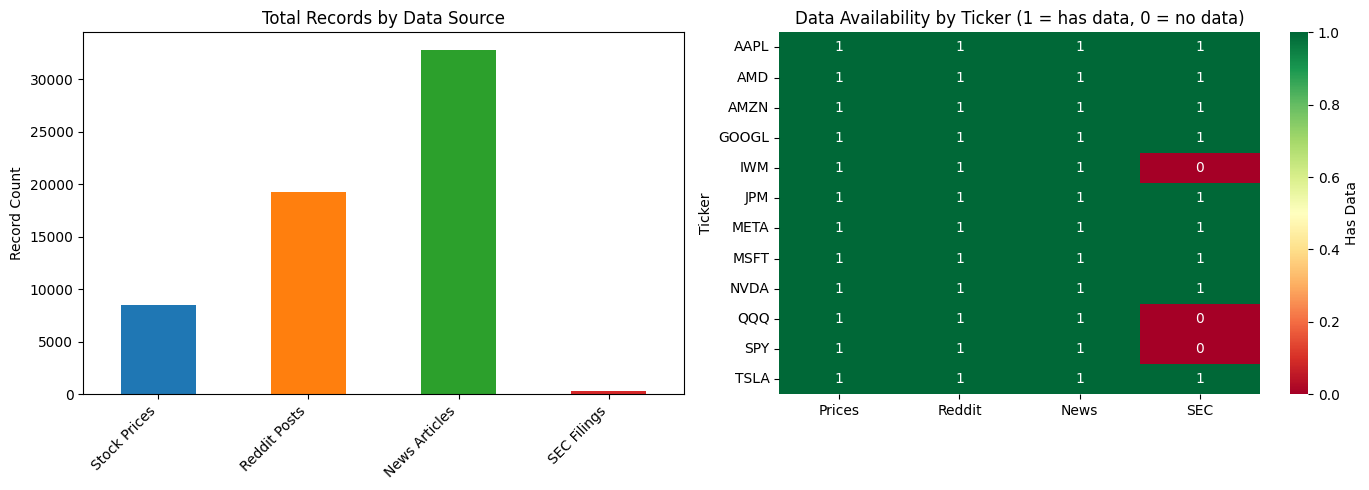


=== DATA COMPLETENESS SUMMARY ===

Tickers with all 4 sources: 9
Tickers with 3+ sources: 12
Tickers with <3 sources: 0

Top 3 tickers by total records:
symbol  total_records  sources_present
  AAPL           7124                4
   AMD           4550                4
  AMZN           4736                4

Tickers with most complete data (all 4 sources):
symbol  price_records  reddit_records  news_records  sec_records  total_records
  AAPL            711             897          5480           36           7124
   AMD            711            1789          2005           45           4550
  AMZN            711             921          3067           37           4736
 GOOGL            711             538          4205           46           5500
   JPM            711             233          1948           26           2918
  META            711             794          2187           22           3714
  MSFT            711             932          3384           39           5066


In [10]:
# Visualize data completeness by source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Records by source
sources = ['price_records', 'reddit_records', 'news_records', 'sec_records']
source_totals = completeness_df[sources].sum()
source_totals.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Total Records by Data Source')
axes[0].set_ylabel('Record Count')
axes[0].set_xticklabels(['Stock Prices', 'Reddit Posts', 'News Articles', 'SEC Filings'], rotation=45, ha='right')

# Heatmap: Data availability by ticker
pivot_df = completeness_df[['symbol', 'price_records', 'reddit_records', 'news_records', 'sec_records']].copy()
pivot_df.columns = ['Ticker', 'Prices', 'Reddit', 'News', 'SEC']
pivot_df = pivot_df.set_index('Ticker')
pivot_df = (pivot_df > 0).astype(int)  # Convert to binary (has data or not)
sns.heatmap(pivot_df, annot=True, cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Has Data'})
axes[1].set_title('Data Availability by Ticker (1 = has data, 0 = no data)')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== DATA COMPLETENESS SUMMARY ===")
print(f"\nTickers with all 4 sources: {(completeness_df['sources_present'] == 4).sum()}")
print(f"Tickers with 3+ sources: {(completeness_df['sources_present'] >= 3).sum()}")
print(f"Tickers with <3 sources: {(completeness_df['sources_present'] < 3).sum()}")

print("\nTop 3 tickers by total records:")
print(completeness_df[['symbol', 'total_records', 'sources_present']].head(3).to_string(index=False))

print("\nTickers with most complete data (all 4 sources):")
complete_tickers = completeness_df[completeness_df['sources_present'] == 4]
if len(complete_tickers) > 0:
    print(complete_tickers[['symbol', 'price_records', 'reddit_records', 'news_records', 'sec_records', 'total_records']].to_string(index=False))
else:
    print("No tickers have all 4 data sources.")

In [11]:
# Analyze temporal coverage and overlaps - using separate queries for speed
import matplotlib.dates as mdates

# Query each source separately for date ranges
price_dates = pd.read_sql("""
SELECT ticker_id, MIN(date) as price_start, MAX(date) as price_end 
FROM stock_prices GROUP BY ticker_id
""", engine)

reddit_dates = pd.read_sql("""
SELECT DISTINCT rpt.ticker_id, 
    MIN(rp.trading_date) as reddit_start, 
    MAX(rp.trading_date) as reddit_end
FROM reddit_post_tickers rpt
JOIN reddit_posts rp ON rpt.reddit_post_id = rp.reddit_post_id
GROUP BY rpt.ticker_id
""", engine)

news_dates = pd.read_sql("""
SELECT DISTINCT nat.ticker_id, 
    MIN(na.trading_date) as news_start, 
    MAX(na.trading_date) as news_end
FROM news_article_tickers nat
JOIN news_articles na ON nat.news_article_id = na.news_article_id
GROUP BY nat.ticker_id
""", engine)

sec_dates = pd.read_sql("""
SELECT ticker_id, MIN(trading_date) as sec_start, MAX(trading_date) as sec_end 
FROM sec_filings GROUP BY ticker_id
""", engine)

# Merge all in pandas
temporal_df = tickers.copy()
temporal_df = temporal_df.merge(price_dates, on='ticker_id', how='left')
temporal_df = temporal_df.merge(reddit_dates, on='ticker_id', how='left')
temporal_df = temporal_df.merge(news_dates, on='ticker_id', how='left')
temporal_df = temporal_df.merge(sec_dates, on='ticker_id', how='left')

# Convert to datetime
date_cols = ['price_start', 'price_end', 'reddit_start', 'reddit_end', 
             'news_start', 'news_end', 'sec_start', 'sec_end']
for col in date_cols:
    temporal_df[col] = pd.to_datetime(temporal_df[col])

temporal_df['overall_start'] = temporal_df[['price_start', 'reddit_start', 'news_start', 'sec_start']].min(axis=1)
temporal_df['overall_end'] = temporal_df[['price_end', 'reddit_end', 'news_end', 'sec_end']].max(axis=1)
temporal_df['coverage_days'] = (temporal_df['overall_end'] - temporal_df['overall_start']).dt.days

# Calculate overlap - dates where ALL 4 sources have data
temporal_df['overlap_start'] = temporal_df[['price_start', 'reddit_start', 'news_start', 'sec_start']].max(axis=1)
temporal_df['overlap_end'] = temporal_df[['price_end', 'reddit_end', 'news_end', 'sec_end']].min(axis=1)
temporal_df['overlap_days'] = (temporal_df['overlap_end'] - temporal_df['overlap_start']).dt.days
temporal_df['overlap_days'] = temporal_df['overlap_days'].apply(lambda x: max(0, x) if pd.notnull(x) else 0)

print("=== TEMPORAL COVERAGE ANALYSIS ===\n")
print(f"Date range across all data: {temporal_df['overall_start'].min()} to {temporal_df['overall_end'].max()}\n")

print("Top 5 tickers by temporal coverage:")
print(temporal_df.nlargest(5, 'coverage_days')[['symbol', 'overall_start', 'overall_end', 'coverage_days']].to_string(index=False))

print("\n\nTop 5 tickers by overlap (all 4 sources have data):")
overlap_tickers = temporal_df[temporal_df['overlap_days'] > 0].nlargest(5, 'overlap_days')
if len(overlap_tickers) > 0:
    print(overlap_tickers[['symbol', 'overlap_start', 'overlap_end', 'overlap_days']].to_string(index=False))
else:
    print("No tickers have overlapping coverage across all 4 sources.")

# Merge with completeness data
analysis_df = completeness_df.merge(temporal_df, on='symbol', how='left')
analysis_df = analysis_df.sort_values(['sources_present', 'overlap_days'], ascending=False)

print("\n\n=== BEST TICKERS FOR ANALYSIS ===")
print("(Ranked by: 1) Number of sources, 2) Overlap days)")
best_tickers = analysis_df[analysis_df['sources_present'] >= 3].head(10)
if len(best_tickers) > 0:
    print(best_tickers[['symbol', 'sources_present', 'total_records', 'overlap_days', 'overall_start', 'overall_end']].to_string(index=False))
else:
    print("No tickers found with 3+ sources.")

=== TEMPORAL COVERAGE ANALYSIS ===

Date range across all data: 2020-06-12 00:00:00 to 2025-11-20 00:00:00

Top 5 tickers by temporal coverage:
symbol overall_start overall_end  coverage_days
 GOOGL    2020-06-12  2025-11-07           1974
  MSFT    2020-07-23  2025-10-31           1926
  AAPL    2021-04-27  2025-10-31           1648
  AMZN    2023-01-03  2025-11-20           1052
  NVDA    2023-01-03  2025-11-20           1052


Top 5 tickers by overlap (all 4 sources have data):
symbol overlap_start overlap_end  overlap_days
  AAPL    2024-07-01  2025-07-01           365
  MSFT    2024-07-01  2025-06-30           364
 GOOGL    2024-07-03  2025-06-30           362
  NVDA    2024-08-05  2025-07-01           330
  AMZN    2024-10-30  2025-07-01           244


=== BEST TICKERS FOR ANALYSIS ===
(Ranked by: 1) Number of sources, 2) Overlap days)
symbol  sources_present  total_records  overlap_days overall_start overall_end
  AAPL                4           7124           365    2021-04-27

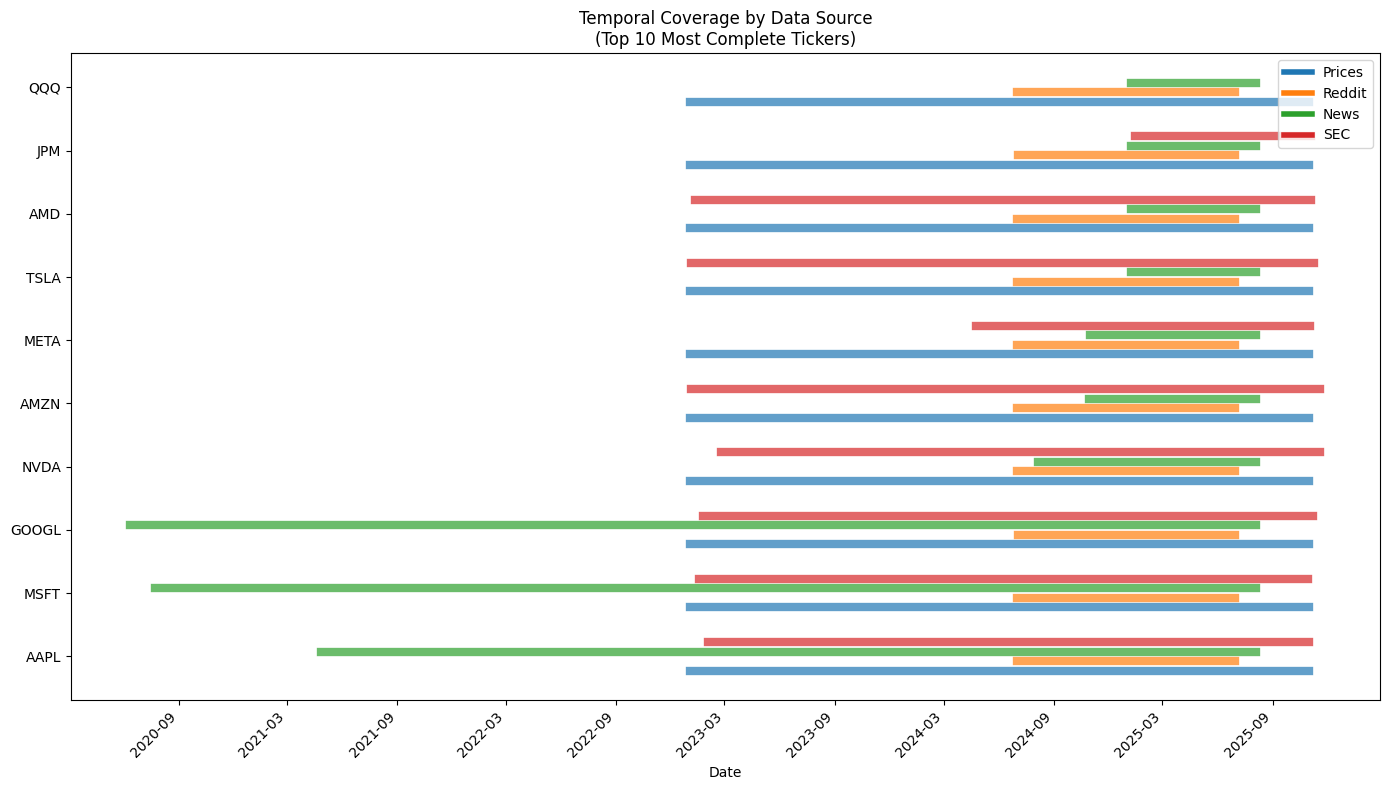

In [12]:
# Visualize temporal coverage for top tickers
top_tickers_for_viz = analysis_df[analysis_df['sources_present'] >= 3].head(10)

if len(top_tickers_for_viz) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    y_pos = np.arange(len(top_tickers_for_viz))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    source_names = ['Prices', 'Reddit', 'News', 'SEC']
    
    for idx, row in top_tickers_for_viz.iterrows():
        ticker_y = y_pos[list(top_tickers_for_viz.index).index(idx)]
        
        # Plot date range for each source
        sources = [
            ('price_start', 'price_end', colors[0]),
            ('reddit_start', 'reddit_end', colors[1]),
            ('news_start', 'news_end', colors[2]),
            ('sec_start', 'sec_end', colors[3])
        ]
        
        for i, (start_col, end_col, color) in enumerate(sources):
            start = row[start_col]
            end = row[end_col]
            if pd.notnull(start) and pd.notnull(end):
                ax.plot([start, end], [ticker_y + i*0.15 - 0.225, ticker_y + i*0.15 - 0.225], 
                       linewidth=6, color=color, alpha=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_tickers_for_viz['symbol'])
    ax.set_xlabel('Date')
    ax.set_title('Temporal Coverage by Data Source\n(Top 10 Most Complete Tickers)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')
    
    # Create legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=source_names[i]) 
                      for i in range(4)]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No tickers with 3+ sources to visualize.")

# Single Source Analaysis

## Stock Prices:

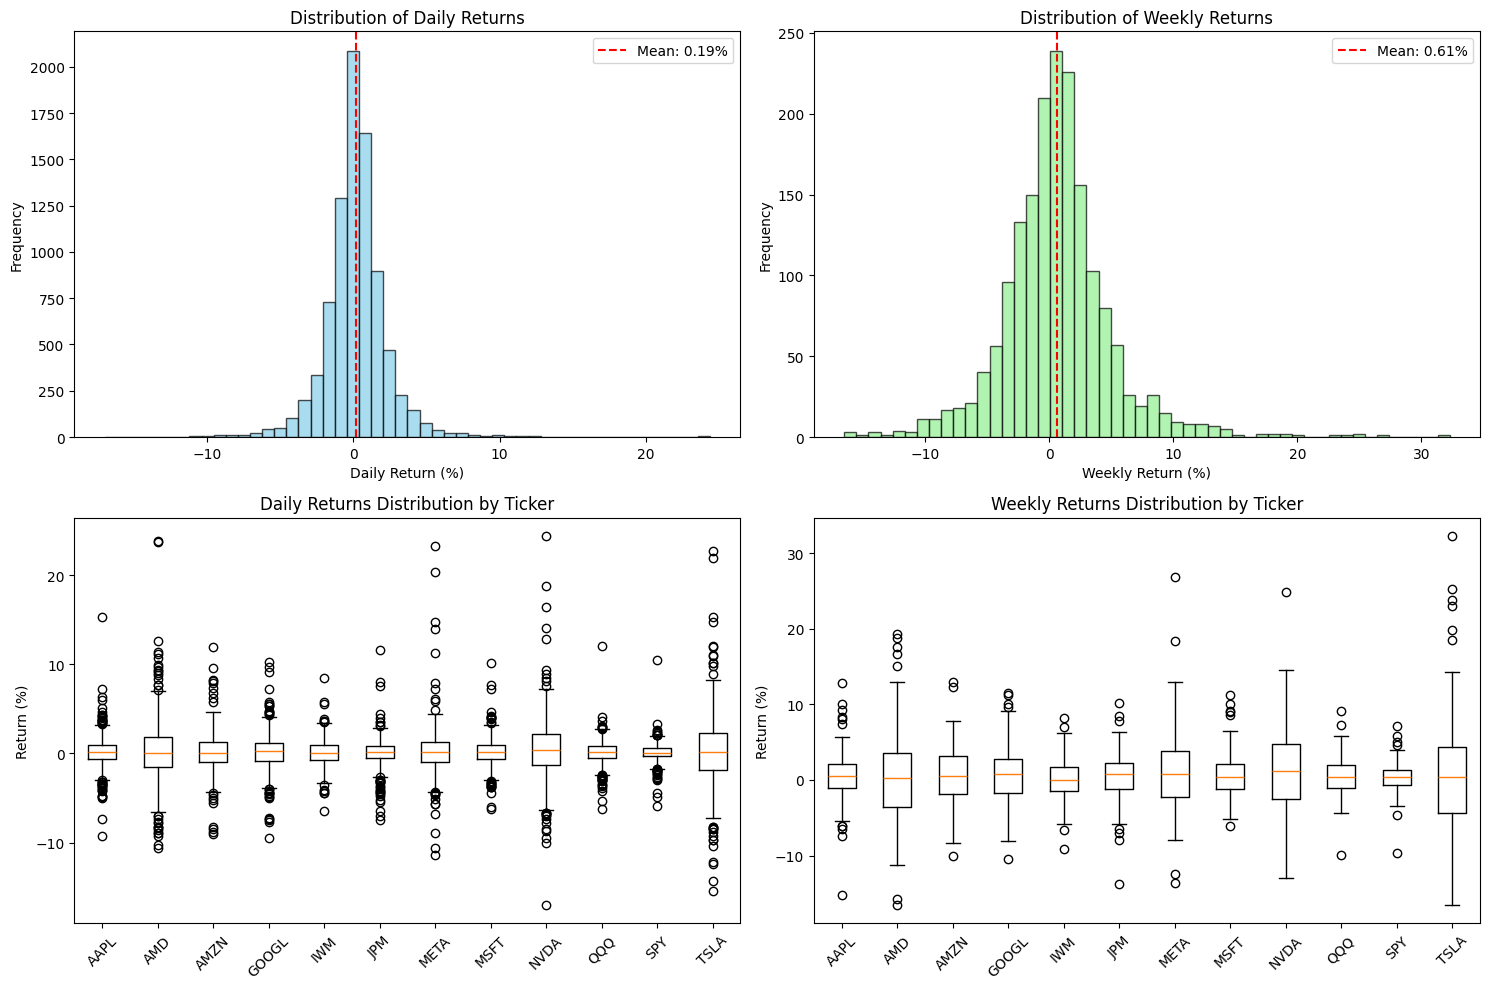

=== RETURNS DISTRIBUTION SUMMARY ===

Daily Returns Statistics:
Mean: 0.1860%
Std Dev: 2.2515%
Min: -16.9682%
Max: 24.3699%
Skewness: 1.0990
Kurtosis: 14.3166

Weekly Returns Statistics:
Mean: 0.6097%
Std Dev: 4.4234%
Min: -16.5272%
Max: 32.2764%


Daily Returns by Ticker:
            mean       std        min        max
symbol                                          
AAPL    0.124032  1.646093  -9.245587  15.328832
AMD     0.248038  3.279634 -10.616541  23.820483
AMZN    0.167927  2.031103  -8.979134  11.977030
GOOGL   0.181019  1.904313  -9.509396  10.224369
IWM     0.063250  1.345029  -6.419624   8.500160
JPM     0.138484  1.453148  -7.483855  11.544524
META    0.262115  2.443511 -11.334753  23.282397
MSFT    0.122479  1.474609  -6.180907  10.133683
NVDA    0.424399  3.203880 -16.968179  24.369932
QQQ     0.132432  1.267777  -6.210871  12.003076
SPY     0.092016  0.977869  -5.854307  10.501945
TSLA    0.275563  3.832427 -15.426200  22.689985


In [13]:
# Task 1: Distribution of Returns (Daily & Weekly)

# Get stock prices with ticker info
stock_prices_df = pd.read_sql("""
SELECT sp.*, t.symbol
FROM stock_prices sp
JOIN tickers t ON sp.ticker_id = t.ticker_id
ORDER BY t.symbol, sp.date
""", engine)

stock_prices_df['date'] = pd.to_datetime(stock_prices_df['date'])

# Calculate daily returns
stock_prices_df['daily_return'] = stock_prices_df.groupby('symbol')['close'].pct_change() * 100

# Calculate weekly returns
stock_prices_df['week'] = stock_prices_df['date'].dt.isocalendar().week
stock_prices_df['year'] = stock_prices_df['date'].dt.isocalendar().year
weekly_returns = stock_prices_df.groupby(['symbol', 'year', 'week']).agg({
    'close': ['first', 'last']
}).reset_index()
weekly_returns.columns = ['symbol', 'year', 'week', 'open_price', 'close_price']
weekly_returns['weekly_return'] = ((weekly_returns['close_price'] - weekly_returns['open_price']) / weekly_returns['open_price'] * 100)

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Daily returns histogram
axes[0, 0].hist(stock_prices_df['daily_return'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Distribution of Daily Returns')
axes[0, 0].set_xlabel('Daily Return (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(stock_prices_df['daily_return'].mean(), color='red', linestyle='--', label=f"Mean: {stock_prices_df['daily_return'].mean():.2f}%")
axes[0, 0].legend()

# Weekly returns histogram
axes[0, 1].hist(weekly_returns['weekly_return'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Distribution of Weekly Returns')
axes[0, 1].set_xlabel('Weekly Return (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(weekly_returns['weekly_return'].mean(), color='red', linestyle='--', label=f"Mean: {weekly_returns['weekly_return'].mean():.2f}%")
axes[0, 1].legend()

# Daily returns by ticker (box plot)
daily_by_ticker = stock_prices_df.dropna(subset=['daily_return']).groupby('symbol')['daily_return'].apply(list).to_dict()
axes[1, 0].boxplot(daily_by_ticker.values(), labels=daily_by_ticker.keys())
axes[1, 0].set_title('Daily Returns Distribution by Ticker')
axes[1, 0].set_ylabel('Return (%)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Weekly returns by ticker (box plot)
weekly_by_ticker = weekly_returns.dropna(subset=['weekly_return']).groupby('symbol')['weekly_return'].apply(list).to_dict()
axes[1, 1].boxplot(weekly_by_ticker.values(), labels=weekly_by_ticker.keys())
axes[1, 1].set_title('Weekly Returns Distribution by Ticker')
axes[1, 1].set_ylabel('Return (%)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("=== RETURNS DISTRIBUTION SUMMARY ===\n")
print("Daily Returns Statistics:")
print(f"Mean: {stock_prices_df['daily_return'].mean():.4f}%")
print(f"Std Dev: {stock_prices_df['daily_return'].std():.4f}%")
print(f"Min: {stock_prices_df['daily_return'].min():.4f}%")
print(f"Max: {stock_prices_df['daily_return'].max():.4f}%")
print(f"Skewness: {stock_prices_df['daily_return'].skew():.4f}")
print(f"Kurtosis: {stock_prices_df['daily_return'].kurtosis():.4f}")

print("\nWeekly Returns Statistics:")
print(f"Mean: {weekly_returns['weekly_return'].mean():.4f}%")
print(f"Std Dev: {weekly_returns['weekly_return'].std():.4f}%")
print(f"Min: {weekly_returns['weekly_return'].min():.4f}%")
print(f"Max: {weekly_returns['weekly_return'].max():.4f}%")

print("\n\nDaily Returns by Ticker:")
daily_stats = stock_prices_df.dropna(subset=['daily_return']).groupby('symbol')['daily_return'].agg(['mean', 'std', 'min', 'max'])
print(daily_stats.to_string())

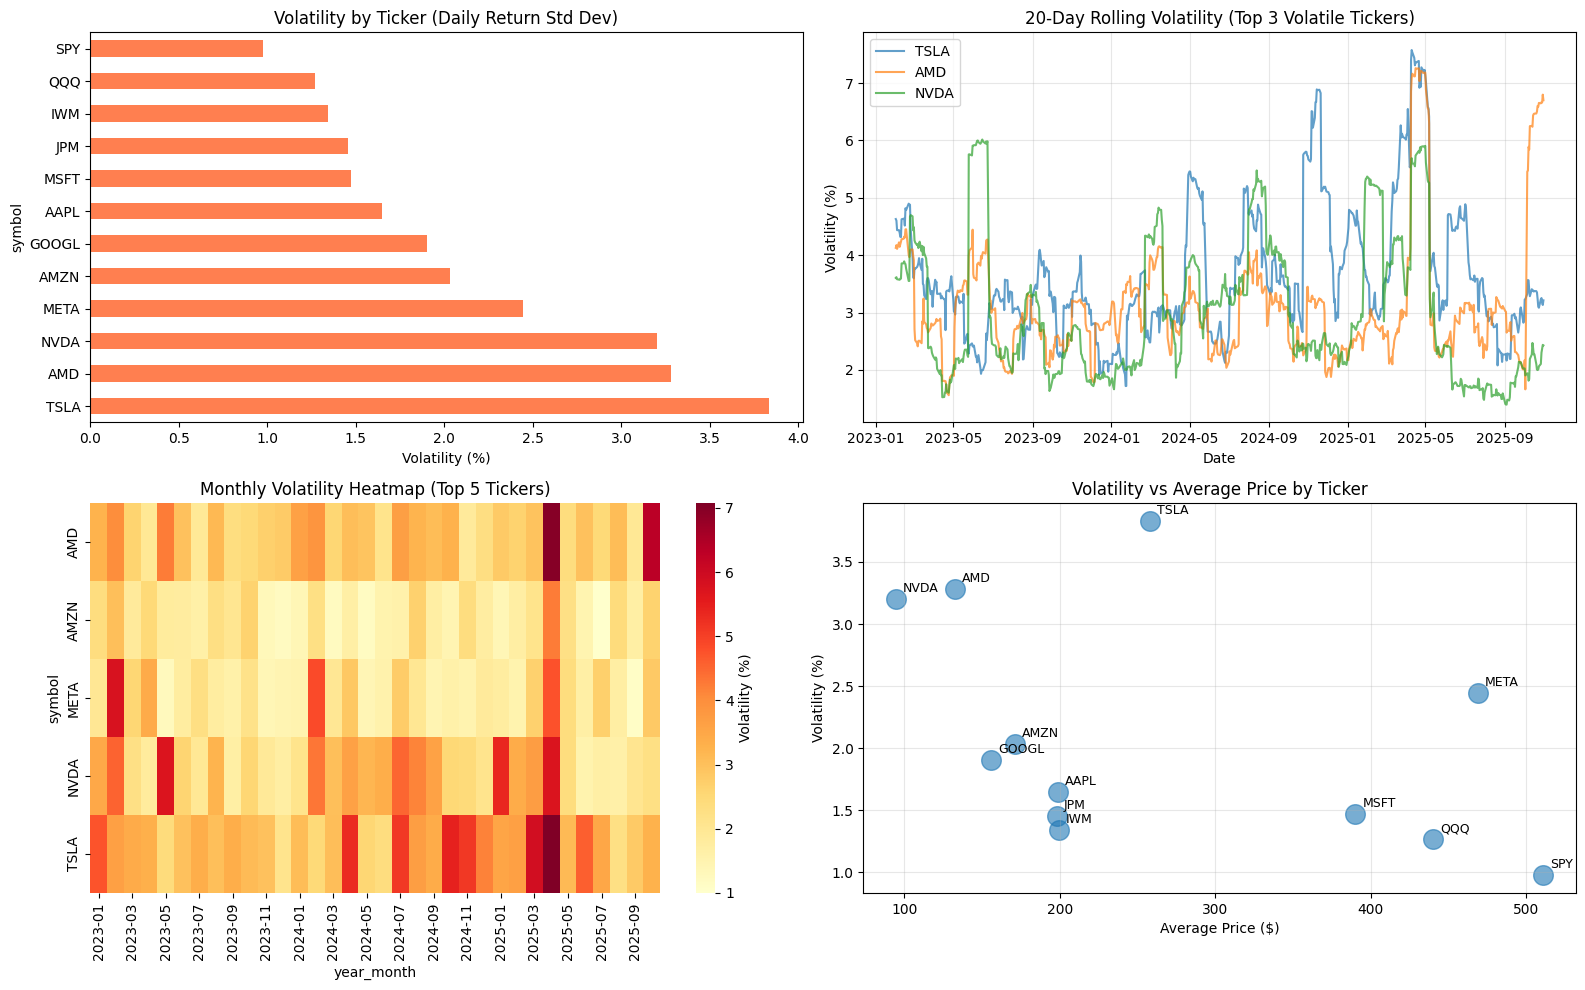

=== VOLATILITY ANALYSIS ===

Volatility by Ticker (sorted by highest to lowest):
        volatility  avg_price  num_records
symbol                                    
TSLA        3.8324   258.0967          711
AMD         3.2796   132.8633          711
NVDA        3.2039    94.4925          711
META        2.4435   469.0798          711
AMZN        2.0311   171.2445          711
GOOGL       1.9043   155.6853          711
AAPL        1.6461   198.6008          711
MSFT        1.4746   390.1846          711
JPM         1.4531   198.2346          711
IWM         1.3450   199.5380          711
QQQ         1.2678   440.1449          711
SPY         0.9779   511.1817          711


Top 5 Most Volatile Tickers:
        volatility  avg_price  num_records
symbol                                    
TSLA        3.8324   258.0967          711
AMD         3.2796   132.8633          711
NVDA        3.2039    94.4925          711
META        2.4435   469.0798          711
AMZN        2.0311   171.244

In [ ]:
# Task 2: Volatility Patterns by Ticker & Sector

# Get sector information
sectors_df = pd.read_sql("SELECT ticker_id, symbol, sector FROM tickers", engine)
stock_prices_df = stock_prices_df.merge(sectors_df[['ticker_id', 'sector']], on='ticker_id', how='left')

# Calculate rolling volatility (20-day window)
stock_prices_df['volatility_20d'] = stock_prices_df.groupby('symbol')['daily_return'].transform(
    lambda x: x.rolling(window=20).std()
)

# Calculate volatility by month and ticker
stock_prices_df['year_month'] = stock_prices_df['date'].dt.to_period('M')
monthly_volatility = stock_prices_df.groupby(['symbol', 'year_month'])['daily_return'].std().reset_index()
monthly_volatility.columns = ['symbol', 'year_month', 'volatility']

# Overall volatility by ticker
ticker_volatility = stock_prices_df.groupby('symbol').agg({
    'daily_return': 'std',
    'close': ['mean', 'count'],
    'sector': 'first'
}).round(4)
ticker_volatility.columns = ['volatility', 'avg_price', 'num_records', 'sector']
ticker_volatility = ticker_volatility.sort_values('volatility', ascending=False)

# Volatility by sector
sector_volatility = stock_prices_df.groupby('sector').agg({
    'daily_return': ['mean', 'std'],
    'symbol': 'nunique'
}).round(4)
sector_volatility.columns = ['avg_return', 'volatility', 'num_tickers']
sector_volatility = sector_volatility.sort_values('volatility', ascending=False)

# Visualize volatility patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Volatility by ticker (bar chart)
ticker_volatility['volatility'].plot(kind='barh', ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Volatility by Ticker (Daily Return Std Dev)')
axes[0, 0].set_xlabel('Volatility (%)')

# 2. Volatility by sector (bar chart)
sector_volatility['volatility'].plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Volatility by Sector')
axes[0, 1].set_ylabel('Volatility (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Rolling volatility over time for top 3 most volatile tickers
top_3_volatile = ticker_volatility.nlargest(3, 'volatility').index
for ticker in top_3_volatile:
    ticker_data = stock_prices_df[stock_prices_df['symbol'] == ticker].sort_values('date')
    axes[0, 2].plot(ticker_data['date'], ticker_data['volatility_20d'], label=ticker, alpha=0.7)
axes[0, 2].set_title('20-Day Rolling Volatility (Top 3 Volatile Tickers)')
axes[0, 2].set_xlabel('Date')
axes[0, 2].set_ylabel('Volatility (%)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Monthly volatility heatmap (top 5 tickers)
top_5_tickers = ticker_volatility.nlargest(5, 'volatility').index
monthly_vol_pivot = monthly_volatility[monthly_volatility['symbol'].isin(top_5_tickers)].pivot(
    index='symbol', columns='year_month', values='volatility'
)
sns.heatmap(monthly_vol_pivot, cmap='YlOrRd', ax=axes[1, 0], cbar_kws={'label': 'Volatility (%)'})
axes[1, 0].set_title('Monthly Volatility Heatmap (Top 5 Tickers)')

# 5. Volatility vs Average Price scatter (colored by sector)
sectors = stock_prices_df['sector'].unique()
colors_map = {sector: plt.cm.tab20(i) for i, sector in enumerate(sectors)}
for sector in sectors:
    sector_data = ticker_volatility[ticker_volatility['sector'] == sector]
    axes[1, 1].scatter(sector_data['avg_price'], sector_data['volatility'], 
                      label=sector, s=200, alpha=0.6, color=colors_map.get(sector, 'gray'))
axes[1, 1].set_xlabel('Average Price ($)')
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].set_title('Volatility vs Average Price (by Sector)')
axes[1, 1].legend(fontsize=8, loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

# 6. Box plot: Returns by sector
sector_returns_data = [stock_prices_df[stock_prices_df['sector'] == sector]['daily_return'].dropna().values 
                       for sector in sorted(stock_prices_df['sector'].dropna().unique())]
axes[1, 2].boxplot(sector_returns_data, labels=sorted(stock_prices_df['sector'].dropna().unique()))
axes[1, 2].set_title('Daily Returns Distribution by Sector')
axes[1, 2].set_ylabel('Return (%)')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("=== VOLATILITY ANALYSIS ===\n")
print("Volatility by Ticker (sorted by highest to lowest):")
print(ticker_volatility.to_string())

print("\n\nVolatility by Sector:")
print(sector_volatility.to_string())

print("\n\nTop 5 Most Volatile Tickers:")
print(ticker_volatility.head(5).to_string())

print("\n\nTop 5 Least Volatile Tickers:")
print(ticker_volatility.tail(5).to_string())

print("\n\nSector Rankings:")
print("Most volatile sectors:")
print(sector_volatility.head(3).to_string())
print("\nLeast volatile sectors:")
print(sector_volatility.tail(3).to_string())

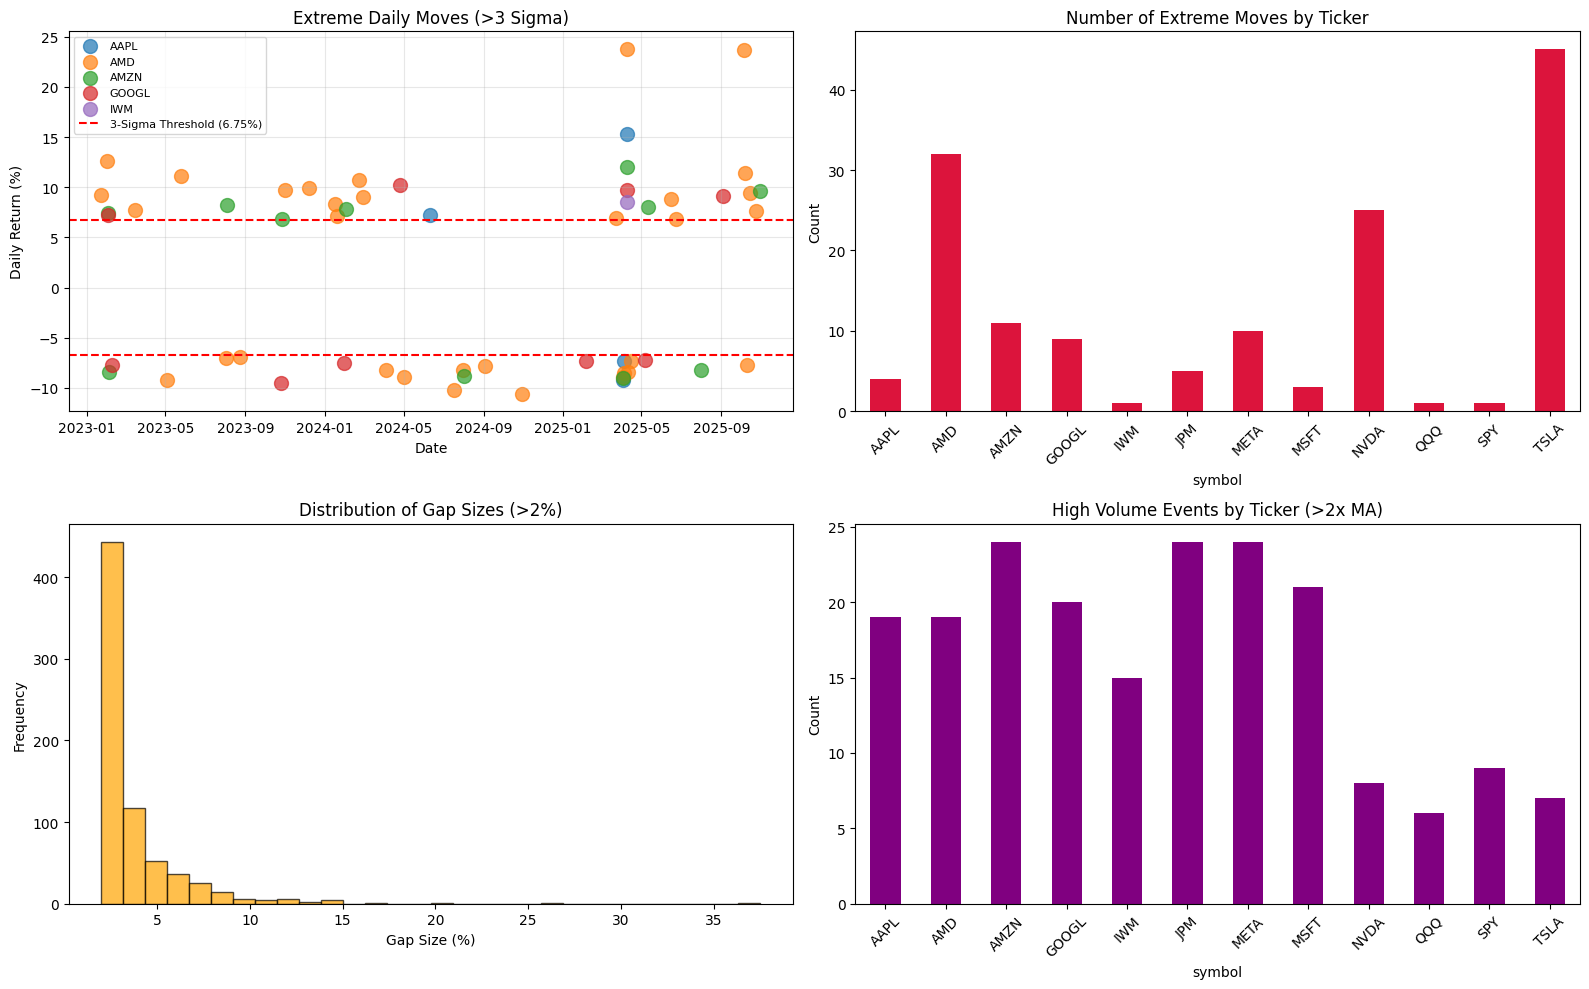

=== ANOMALY DETECTION REPORT ===

EXTREME MOVES (>3 Sigma, >6.75%):
Total extreme moves: 147

Top 10 most extreme moves:
      date symbol  daily_return    close     volume
2023-05-25   NVDA     24.369932  37.9485 1543911000
2025-04-09    AMD     23.820483  96.8400   97827400
2025-10-06    AMD     23.708022 203.7100  248859600
2023-02-02   META     23.282397 187.4605  150475700
2025-04-09   TSLA     22.689985 272.2000  219433400
2024-10-24   TSLA     21.919026 260.4800  204491900
2024-02-02   META     20.317645 471.6951   84707600
2025-04-09   NVDA     18.722821 114.3093  612918300
2024-02-22   NVDA     16.400976  78.4943  865100000
2025-04-09   AAPL     15.328832 198.1723  184395900


GAP ANALYSIS (>2%):
Total gaps >2%: 714

Top 10 largest gaps:
      date symbol  gap_size  is_gap_up  is_gap_down
2025-10-06    AMD 37.517459       True        False
2023-05-25   NVDA 26.147886       True        False
2023-02-02   META 19.762288       True        False
2024-02-02   META 16.419257       T

In [15]:
# Task 3: Identify Anomalies and Suspicious Patterns

# Define anomaly detection thresholds
daily_return_mean = stock_prices_df['daily_return'].mean()
daily_return_std = stock_prices_df['daily_return'].std()
extreme_move_threshold = 3 * daily_return_std  # 3-sigma rule

# Detect anomalies
stock_prices_df['is_extreme_move'] = stock_prices_df['daily_return'].abs() > extreme_move_threshold
stock_prices_df['is_gap_up'] = stock_prices_df.groupby('symbol')['close'].shift(1) < stock_prices_df['open']
stock_prices_df['is_gap_down'] = stock_prices_df.groupby('symbol')['close'].shift(1) > stock_prices_df['open']

# Calculate gap size
stock_prices_df['gap_size'] = abs((stock_prices_df['open'] - stock_prices_df.groupby('symbol')['close'].shift(1)) / 
                                  stock_prices_df.groupby('symbol')['close'].shift(1) * 100)

# Detect unusual volume (if available)
stock_prices_df['volume_ma_20'] = stock_prices_df.groupby('symbol')['volume'].transform(
    lambda x: x.rolling(window=20).mean()
)
stock_prices_df['volume_ratio'] = stock_prices_df['volume'] / stock_prices_df['volume_ma_20']
stock_prices_df['is_high_volume'] = stock_prices_df['volume_ratio'] > 2

# Find anomalies
extreme_moves = stock_prices_df[stock_prices_df['is_extreme_move']].copy()
large_gaps = stock_prices_df[(stock_prices_df['is_gap_up'] | stock_prices_df['is_gap_down']) & 
                             (stock_prices_df['gap_size'] > 2)].copy()
high_volume_moves = stock_prices_df[stock_prices_df['is_high_volume']].copy()

# Visualize anomalies
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Extreme moves timeline
for ticker in stock_prices_df['symbol'].unique()[:5]:  # Show first 5 tickers
    ticker_extreme = extreme_moves[extreme_moves['symbol'] == ticker]
    if len(ticker_extreme) > 0:
        axes[0, 0].scatter(ticker_extreme['date'], ticker_extreme['daily_return'], 
                          label=ticker, s=100, alpha=0.7)
axes[0, 0].axhline(y=extreme_move_threshold, color='red', linestyle='--', 
                   label=f'3-Sigma Threshold ({extreme_move_threshold:.2f}%)')
axes[0, 0].axhline(y=-extreme_move_threshold, color='red', linestyle='--')
axes[0, 0].set_title('Extreme Daily Moves (>3 Sigma)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Daily Return (%)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Extreme moves by ticker
extreme_by_ticker = stock_prices_df[stock_prices_df['is_extreme_move']].groupby('symbol').size()
extreme_by_ticker.plot(kind='bar', ax=axes[0, 1], color='crimson')
axes[0, 1].set_title('Number of Extreme Moves by Ticker')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Gap distribution
gap_data = large_gaps.dropna(subset=['gap_size'])
axes[1, 0].hist(gap_data['gap_size'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title(f'Distribution of Gap Sizes (>2%)')
axes[1, 0].set_xlabel('Gap Size (%)')
axes[1, 0].set_ylabel('Frequency')

# High volume events
volume_by_ticker = stock_prices_df[stock_prices_df['is_high_volume']].groupby('symbol').size()
volume_by_ticker.plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('High Volume Events by Ticker (>2x MA)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print detailed anomaly reports
print("=== ANOMALY DETECTION REPORT ===\n")

print(f"EXTREME MOVES (>3 Sigma, >{extreme_move_threshold:.2f}%):")
print(f"Total extreme moves: {len(extreme_moves)}")
print("\nTop 10 most extreme moves:")
print(extreme_moves.nlargest(10, 'daily_return')[['date', 'symbol', 'daily_return', 'close', 'volume']].to_string(index=False))

print(f"\n\nGAP ANALYSIS (>2%):")
print(f"Total gaps >2%: {len(large_gaps)}")
if len(large_gaps) > 0:
    print("\nTop 10 largest gaps:")
    print(large_gaps.nlargest(10, 'gap_size')[['date', 'symbol', 'gap_size', 'is_gap_up', 'is_gap_down']].to_string(index=False))

print(f"\n\nHIGH VOLUME EVENTS (>2x 20-day average):")
print(f"Total high volume events: {len(high_volume_moves)}")
high_vol_summary = stock_prices_df[stock_prices_df['is_high_volume']].groupby('symbol').size().sort_values(ascending=False)
print("\nHigh volume events by ticker:")
print(high_vol_summary.to_string())

print("\n\nSUSPICIOUS PATTERNS - Extreme Moves + High Volume (potential manipulation/events):")
suspicious = stock_prices_df[stock_prices_df['is_extreme_move'] & stock_prices_df['is_high_volume']]
print(f"Total suspicious events: {len(suspicious)}")
if len(suspicious) > 0:
    print("\nDetailed view:")
    print(suspicious[['date', 'symbol', 'daily_return', 'volume_ratio', 'gap_size']].head(20).to_string(index=False))